# Mumbai Indians (2024–2026): Hypothesis Testing

This notebook applies formal statistical testing to the findings developed across the companion **Bowling Analysis** and **Batting Analysis** notebooks. Those notebooks are descriptive — means, rates, and season-over-season comparisons. This one asks the harder question for the sharpest claims: **is the pattern real, or could it plausibly be noise?**

Season-level data (n=3) is too small for meaningful testing on its own — several tests here drop down to per-match or per-innings granularity specifically to get real statistical power, the same approach used for Surya's survival-profile analysis in the Batting notebook.

**Ten hypotheses are tested, split across four categories:**

1. **Bowling trend & comparison tests** (H1–H4): Bumrah's decline, MI's death-overs relapse, Jacks' LHB/RHB split, Ashwani Kumar's workload cut.
2. **Batting trend & comparison tests** (H5–H8): Tilak's rising trend, the Tilak-vs-Hardik 2026 gap, Rickelton's improvement, Surya's powerplay dismissal spike.
3. **Correlation tests** (H9): batting-position instability vs. performance.
4. **The case study's central thesis, tested directly** (H10): does MI's bowler rotation/churn actually correlate with worse economy, or has that claim only ever been asserted qualitatively?

**A note on method before starting:** the right test depends on the data shape, not habit — Welch's t-test for two-group comparisons with unequal variance, Pearson correlation for trend questions, Mann-Whitney U where the underlying data (runs off a single ball) is too skewed for a t-test's normality assumption, and Fisher's exact test for small 2×2 count tables rather than a chi-square test, which needs larger expected cell counts to be reliable. Each section states which test is used and why before running it.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

# Okabe-Ito palette — colorblind-safe, consistent with the companion notebooks
GRAY = "#999999"
ACCENT = "#D55E00"
BLUE = "#0072B2"
GREEN = "#009E73"
INK = "1A1A1A"

ALPHA = 0.05  # standard significance threshold used throughout this notebook


## 2. Load and prepare data

The same pipeline as both companion notebooks — ball-by-ball data merged with match metadata, filtered to 2024–2026, phase-tagged. Reproduced here rather than imported so this notebook runs standalone.

In [2]:
ball_data = pd.read_csv("../data/Ball_By_Ball_Match_Data.csv")
match_data = pd.read_csv("../data/Match_Info.csv")
match_data['match_date'] = pd.to_datetime(match_data['match_date'])
match_data['season'] = match_data['match_date'].dt.year

years = [2024, 2025, 2026]
matches_relevant = match_data[match_data['season'].isin(years)]

final_data = pd.merge(
    ball_data,
    matches_relevant[['match_number', 'season', 'team1', 'team2', 'venue', 'match_date', 'winner']],
    left_on="ID", right_on="match_number", how="inner"
)
final_data = final_data.drop(columns=['match_number'])
final_data['BowlingTeam'] = final_data.apply(
    lambda r: r['team2'] if r['BattingTeam'] == r['team1'] else r['team1'], axis=1
)

def get_phase(over):
    if over < 6:
        return "powerplay"
    elif over < 15:
        return "middle"
    else:
        return "death"

final_data['phase'] = final_data['Overs'].apply(get_phase)
final_data['is_legal_ball'] = ~final_data['ExtraType'].isin(['wides', 'noballs', 'byes,noballs', 'legbyes,noballs'])

phase_order = ['powerplay', 'middle', 'death']

mi_bowling = final_data[final_data['BowlingTeam'] == 'Mumbai Indians']
mi_batting = final_data[final_data['BattingTeam'] == 'Mumbai Indians']

print(f"Rows: {len(final_data)} | MI bowling rows: {len(mi_bowling)} | MI batting rows: {len(mi_batting)}")


Rows: 51915 | MI bowling rows: 5277 | MI batting rows: 5239


## 3. Player metadata (needed for the Jacks LHB/RHB test)

Same patch as the companion notebooks — three current MI players missing from the source metadata file.

In [3]:
meta = pd.read_csv("../data/2024_players_details.csv")
meta = meta[["Name", "longName", "battingName", "battingStyles", "bowlingStyles"]]

missing_players = pd.DataFrame([
    {"Name": "RD Rickelton", "longName": "Ryan Rickelton", "battingName": "RD Rickelton", "battingStyles": "lhb", "bowlingStyles": "sla"},
    {"Name": "Ashwani Kumar", "longName": "Ashwani Kumar", "battingName": "Ashwani Kumar", "battingStyles": "lhb", "bowlingStyles": "lmf"},
    {"Name": "Corbin Bosch", "longName": "Corbin Bosch", "battingName": "Corbin Bosch", "battingStyles": "rhb", "bowlingStyles": "rfm"},
])
meta = pd.concat([meta, missing_players], ignore_index=True)

final_data = final_data.merge(
    meta.rename(columns={"battingName": "Batter", "battingStyles": "batter_hand"})[["Batter", "batter_hand"]],
    on="Batter", how="left"
)

# patch the 8 opposition batters identified as missing in the Batting notebook
lhb_patch = ['C Connolly', 'JG Bethell', 'V Suryavanshi']
rhb_patch = ['V Nigam', 'Akshat Raghuwanshi', 'Nithish Kumar Reddy', 'Dhruv Jurel', 'JP Inglis']
final_data.loc[final_data['Batter'].isin(lhb_patch), 'batter_hand'] = 'lhb'
final_data.loc[final_data['Batter'].isin(rhb_patch), 'batter_hand'] = 'rhb'

mi_bowling = final_data[final_data['BowlingTeam'] == 'Mumbai Indians']  # refresh with batter_hand attached


## 4. Bowling hypotheses

### H1 — Bumrah's economy has genuinely worsened over time

**H0:** There is no linear relationship between season and Bumrah's per-match economy.
**H1:** His per-match economy has trended upward (worse) across 2024–2026.

**Test:** Pearson correlation between season (as a numeric time index) and his economy in each individual match he bowled — using per-match granularity gives real degrees of freedom instead of the 3-point season-level trend the companion notebook could only describe visually.

In [4]:
bumrah_matches = mi_bowling[mi_bowling['Bowler'] == 'JJ Bumrah'].groupby(['ID', 'season']).agg(
    runs_conceded=('TotalRun', 'sum'),
    legal_balls=('is_legal_ball', 'sum'),
).reset_index()
bumrah_matches = bumrah_matches[bumrah_matches['legal_balls'] > 0]
bumrah_matches['economy'] = (bumrah_matches['runs_conceded'] / bumrah_matches['legal_balls'] * 6).round(2)

r, p = stats.pearsonr(bumrah_matches['season'], bumrah_matches['economy'])
print(f"n = {len(bumrah_matches)} matches")
print(f"Pearson r = {r:.3f}, p = {p:.4f}")
print(f"{'REJECT' if p < ALPHA else 'FAIL TO REJECT'} H0 at alpha = {ALPHA}")


n = 38 matches
Pearson r = 0.324, p = 0.0474
REJECT H0 at alpha = 0.05


**Finding — CONFIRMED. Bumrah's economy has genuinely worsened over time, not just across three noisy season-level points.**

r = 0.324, p = 0.0474 — significant at the 0.05 threshold, though only just. At 38 real matches instead of 3 season averages, this is a legitimate trend, not an artifact of picking convenient endpoints. It's a moderate correlation, not an overwhelming one (r² ≈ 0.10, so season only explains about 10% of the match-to-match variation in his economy) — his decline is real, but individual matches still vary a lot for other reasons.

### H2 — MI's team death-overs economy was significantly worse in 2026 than in 2025

**H0:** MI's per-match death-overs economy has the same mean in 2025 and 2026.
**H1:** 2026's mean is higher (worse) than 2025's.

**Test:** Welch's t-test (unequal variance assumed) on per-match death-overs economy, one-sided since the companion notebook's finding is directional (a relapse, not just "different").

In [5]:
mi_death_matches = mi_bowling[mi_bowling['phase'] == 'death'].groupby(['ID', 'season']).agg(
    runs_conceded=('TotalRun', 'sum'),
    legal_balls=('is_legal_ball', 'sum'),
).reset_index()
mi_death_matches = mi_death_matches[mi_death_matches['legal_balls'] > 0]
mi_death_matches['economy'] = (mi_death_matches['runs_conceded'] / mi_death_matches['legal_balls'] * 6).round(2)

econ_2025 = mi_death_matches[mi_death_matches['season'] == 2025]['economy']
econ_2026 = mi_death_matches[mi_death_matches['season'] == 2026]['economy']

t, p_two_sided = stats.ttest_ind(econ_2026, econ_2025, equal_var=False)
p_one_sided = p_two_sided / 2 if t > 0 else 1 - (p_two_sided / 2)

print(f"n(2025) = {len(econ_2025)}, n(2026) = {len(econ_2026)}")
print(f"mean(2025) = {econ_2025.mean():.2f}, mean(2026) = {econ_2026.mean():.2f}")
print(f"t = {t:.2f}, one-sided p = {p_one_sided:.4f}")
print(f"{'REJECT' if p_one_sided < ALPHA else 'FAIL TO REJECT'} H0 at alpha = {ALPHA}")


n(2025) = 16, n(2026) = 13
mean(2025) = 9.79, mean(2026) = 10.80
t = 0.74, one-sided p = 0.2348
FAIL TO REJECT H0 at alpha = 0.05


**Finding — NOT CONFIRMED at the match level, despite looking dramatic in the season aggregate.**

Per-match means: 9.79 (2025) → 10.80 (2026), p = 0.2348 (one-sided) — nowhere near significant. This is worth reconciling honestly against the companion notebook's headline number (10.12 → 11.22): those are **weighted** season economies (total runs ÷ total balls), while this test uses the **unweighted mean of each match's own economy**, treating a 2-over spell the same as a 5-over spell. The two measure genuinely different things — the weighted version is more representative of actual runs conceded, but it also means this specific test simply doesn't have the power to confirm what the season aggregate suggests. **Downgrade from "confirmed relapse" to "suggested by the season aggregate, not confirmed match-to-match."**

### H3 — Jacks' bowling is genuinely more expensive against right-handers than left-handers

**H0:** The distribution of runs conceded per ball is the same regardless of the batter's hand.
**H1:** Runs per ball are higher against RHB than LHB.

**Test:** Mann-Whitney U, not a t-test — per-ball runs conceded is a highly skewed, mostly-zero-or-small-integer variable (0, 1, 4, 6 dominate), which violates a t-test's normality assumption. Mann-Whitney compares the full distributions without that assumption.

In [6]:
jacks_balls = final_data[
    (final_data['Bowler'] == 'WG Jacks') & (final_data['BowlingTeam'] == 'Mumbai Indians') &
    (final_data['is_legal_ball'])
]

runs_vs_lhb = jacks_balls[jacks_balls['batter_hand'] == 'lhb']['TotalRun']
runs_vs_rhb = jacks_balls[jacks_balls['batter_hand'] == 'rhb']['TotalRun']

u_stat, p = stats.mannwhitneyu(runs_vs_rhb, runs_vs_lhb, alternative='greater')

print(f"n(vs LHB balls) = {len(runs_vs_lhb)}, n(vs RHB balls) = {len(runs_vs_rhb)}")
print(f"mean runs/ball vs LHB = {runs_vs_lhb.mean():.3f}, vs RHB = {runs_vs_rhb.mean():.3f}")
print(f"Mann-Whitney U = {u_stat:.1f}, p = {p:.4f}")
print(f"{'REJECT' if p < ALPHA else 'FAIL TO REJECT'} H0 at alpha = {ALPHA}")


n(vs LHB balls) = 103, n(vs RHB balls) = 34
mean runs/ball vs LHB = 1.408, vs RHB = 1.647
Mann-Whitney U = 1932.5, p = 0.1704
FAIL TO REJECT H0 at alpha = 0.05


**Finding — NOT CONFIRMED at the per-ball level, despite a real-looking gap in season economy.**

Mean runs/ball: 1.408 (LHB) vs 1.647 (RHB), p = 0.1704 — the direction matches the companion notebook's finding, but it doesn't clear the significance bar. With only 34 balls in the RHB sample, this test is genuinely underpowered. **Soften the Batting notebook's original framing ("a real, durable pattern") to "a real difference in the descriptive numbers that a formal test can't yet confirm, given the sample size."**

### H4 — Ashwani Kumar's death-overs share of his own workload dropped significantly

**H0:** The proportion of his overs bowled at the death is the same in 2025 and 2026.
**H1:** The proportion is lower in 2026.

**Test:** Fisher's exact test on a 2×2 table (death vs. other phases, by season) — the standard test for small-count contingency tables, more reliable than chi-square when expected cell counts are small, which they are here given his limited 2026 sample.

In [7]:
ashwani_balls = mi_bowling[(mi_bowling['Bowler'] == 'Ashwani Kumar') & (mi_bowling['is_legal_ball'])]

table = pd.crosstab(
    ashwani_balls['season'],
    ashwani_balls['phase'] == 'death'
)
table.columns = ['other_phase', 'death']
table_25_26 = table.loc[[2025, 2026]]

print("2x2 table (balls bowled):")
print(table_25_26)

odds_ratio, p = stats.fisher_exact(table_25_26.values, alternative='less')
# CORRECTED: odds ratio of 0.24 (< 1) points the hypothesized direction
# (2025 has proportionally more death-overs balls than 2026), so the correct
# one-sided test is 'less' — this replaces the original wrong-tailed 'greater' test.
print(f"\nOdds ratio = {odds_ratio:.2f}, p = {p:.4f}")
print(f"{'REJECT' if p < ALPHA else 'FAIL TO REJECT'} H0 at alpha = {ALPHA}")


2x2 table (balls bowled):
        other_phase  death
season                    
2025             84     39
2026             54      6

Odds ratio = 0.24, p = 0.0008
REJECT H0 at alpha = 0.05


**Finding — CONFIRMED, and strongly. Ashwani Kumar's death-overs share genuinely collapsed from 2025 to 2026.**

Odds ratio = 0.24, p = 0.0008 — well past the 0.05 threshold, on real, sizeable counts (39 of 123 balls at the death in 2025 vs. just 6 of 60 in 2026). This is the second-cleanest confirmation in the notebook after H1, and it directly backs one of the companion Bowling notebook's sharpest individual findings: his reduced death-overs role in 2026 wasn't a small, ambiguous shift — it's a statistically decisive one. *(This test originally had a directional bug — the corrected version above is what produced this result; see the code comment for what changed.)*

## 5. Batting hypotheses

### H5 — Tilak Varma's death-overs strike rate shows a genuine rising trend

**H0:** No linear relationship between season and his per-innings death-overs strike rate.
**H1:** A positive trend exists.

**Test:** Pearson correlation, per-innings granularity (each death-overs innings is one data point, not one per season).

In [8]:
tilak_death_innings = mi_batting[
    (mi_batting['Batter'] == 'Tilak Varma') & (mi_batting['phase'] == 'death')
].groupby(['ID', 'season']).agg(
    runs=('BatsmanRun', 'sum'),
    balls_faced=('is_legal_ball', 'sum'),
).reset_index()
tilak_death_innings = tilak_death_innings[tilak_death_innings['balls_faced'] > 0]
tilak_death_innings['strike_rate'] = (tilak_death_innings['runs'] / tilak_death_innings['balls_faced'] * 100).round(2)

r, p = stats.pearsonr(tilak_death_innings['season'], tilak_death_innings['strike_rate'])
print(f"n = {len(tilak_death_innings)} innings")
print(f"Pearson r = {r:.3f}, p = {p:.4f}")
print(f"{'REJECT' if p < ALPHA else 'FAIL TO REJECT'} H0 at alpha = {ALPHA}")


n = 20 innings
Pearson r = 0.238, p = 0.3128
FAIL TO REJECT H0 at alpha = 0.05


**Finding — NOT CONFIRMED at the per-innings level, despite a clean-looking three-point season trend.**

r = 0.238, p = 0.3128. The season-level numbers (173.81 → 187.76 → 256.67) look like a strong, obvious trend — but with only 20 individual innings and real innings-to-innings variance, a formal correlation test can't confirm the pattern is more than a handful of standout performances driving the season averages. **This is the most important walk-back in this notebook**: the "Tilak's death-overs role has risen every year, cleanly" framing should be stated more cautiously — the direction is right, the statistical confidence isn't there yet.

### H6 — The 2026 Tilak-vs-Hardik death-overs strike-rate gap is statistically real

**H0:** Tilak's and Hardik's 2026 per-innings death-overs strike rates come from the same distribution.
**H1:** Tilak's is higher.

**Test:** Mann-Whitney U rather than a t-test — per-innings counts in this single-season, single-phase cut are almost certainly small (likely under 10 each), where a t-test's assumptions are least reliable. **This is exactly the kind of small-sample comparison to interpret cautiously regardless of the p-value** — treat the result as suggestive, not conclusive, and report the raw n alongside it.

In [9]:
tilak_2026_death = mi_batting[
    (mi_batting['Batter'] == 'Tilak Varma') & (mi_batting['phase'] == 'death') & (mi_batting['season'] == 2026)
].groupby('ID').agg(runs=('BatsmanRun', 'sum'), balls_faced=('is_legal_ball', 'sum')).reset_index()
tilak_2026_death = tilak_2026_death[tilak_2026_death['balls_faced'] > 0]
tilak_2026_death['strike_rate'] = (tilak_2026_death['runs'] / tilak_2026_death['balls_faced'] * 100).round(2)

hardik_2026_death = mi_batting[
    (mi_batting['Batter'] == 'HH Pandya') & (mi_batting['phase'] == 'death') & (mi_batting['season'] == 2026)
].groupby('ID').agg(runs=('BatsmanRun', 'sum'), balls_faced=('is_legal_ball', 'sum')).reset_index()
hardik_2026_death = hardik_2026_death[hardik_2026_death['balls_faced'] > 0]
hardik_2026_death['strike_rate'] = (hardik_2026_death['runs'] / hardik_2026_death['balls_faced'] * 100).round(2)

print(f"n(Tilak) = {len(tilak_2026_death)}, n(Hardik) = {len(hardik_2026_death)}")
print(f"mean SR — Tilak: {tilak_2026_death['strike_rate'].mean():.2f}, Hardik: {hardik_2026_death['strike_rate'].mean():.2f}")

if len(tilak_2026_death) >= 3 and len(hardik_2026_death) >= 3:
    u_stat, p = stats.mannwhitneyu(tilak_2026_death['strike_rate'], hardik_2026_death['strike_rate'], alternative='greater')
    print(f"Mann-Whitney U = {u_stat:.1f}, p = {p:.4f}")
    print(f"{'REJECT' if p < ALPHA else 'FAIL TO REJECT'} H0 at alpha = {ALPHA}")
else:
    print("Sample too small for a meaningful test (n < 3 in at least one group) — report descriptively only.")


n(Tilak) = 7, n(Hardik) = 7
mean SR — Tilak: 207.80, Hardik: 106.55
Mann-Whitney U = 37.5, p = 0.0549
FAIL TO REJECT H0 at alpha = 0.05


**Finding — MARGINAL. The gap is large and the test almost clears significance, landing right at the edge.**

Tilak's mean (207.80) is nearly double Hardik's (106.55) — a real, substantial effect size — and even with an already-generous one-sided test, p = 0.0549 falls just short of 0.05, on only 7 innings each. Worth describing precisely: **"strong, borderline-significant evidence," not "no difference detected."** This is different from H2, H5, H7, and H9, where the effect itself was weak — here the effect is large and the sample is just thin.

### H7 — Rickelton's middle-overs strike rate genuinely improved from 2025 to 2026

**H0:** His per-innings middle-overs strike rate has the same mean in both seasons.
**H1:** 2026's mean is higher.

**Test:** Welch's t-test, one-sided.

In [10]:
rickelton_middle = mi_batting[
    (mi_batting['Batter'] == 'RD Rickelton') & (mi_batting['phase'] == 'middle')
].groupby(['ID', 'season']).agg(runs=('BatsmanRun', 'sum'), balls_faced=('is_legal_ball', 'sum')).reset_index()
rickelton_middle = rickelton_middle[rickelton_middle['balls_faced'] > 0]
rickelton_middle['strike_rate'] = (rickelton_middle['runs'] / rickelton_middle['balls_faced'] * 100).round(2)

sr_2025 = rickelton_middle[rickelton_middle['season'] == 2025]['strike_rate']
sr_2026 = rickelton_middle[rickelton_middle['season'] == 2026]['strike_rate']

t, p_two_sided = stats.ttest_ind(sr_2026, sr_2025, equal_var=False)
p_one_sided = p_two_sided / 2 if t > 0 else 1 - (p_two_sided / 2)

print(f"n(2025) = {len(sr_2025)}, n(2026) = {len(sr_2026)}")
print(f"mean(2025) = {sr_2025.mean():.2f}, mean(2026) = {sr_2026.mean():.2f}")
print(f"t = {t:.2f}, one-sided p = {p_one_sided:.4f}")
print(f"{'REJECT' if p_one_sided < ALPHA else 'FAIL TO REJECT'} H0 at alpha = {ALPHA}")


n(2025) = 7, n(2026) = 6
mean(2025) = 122.82, mean(2026) = 141.82
t = 0.35, one-sided p = 0.3683
FAIL TO REJECT H0 at alpha = 0.05


**Finding — NOT CONFIRMED, and the size of the gap itself shrinks once measured per-innings.**

Per-innings means: 122.82 (2025) → 141.82 (2026), p = 0.3683. Same mechanism as H2: the season aggregate (146.77 → 214.10) is weighted by balls faced, so a few big, high-volume innings pull it up disproportionately, while this test treats every innings equally. **The real, more modest story: Rickelton had a good 2025-to-2026 season, but the dramatic 214.10 headline number was doing more work than the underlying innings-by-innings consistency supports.**

### H8 — Surya's 2026 powerplay dismissal rate is significantly higher than his 2024–2025 baseline

**H0:** His powerplay dismissal rate (dismissals per innings reaching that phase) is the same in 2026 as in 2024–2025 combined.
**H1:** 2026's rate is higher.

**Test:** Fisher's exact test on a 2×2 table (dismissed vs. survived, 2026 vs. 2024-25 combined) — count data, small samples, the same justification as H4.

In [11]:
surya_pp = mi_batting[
    (mi_batting['Batter'] == 'SA Yadav') & (mi_batting['phase'] == 'powerplay')
].sort_values(['ID', 'Innings', 'Overs', 'BallNumber']).groupby(['ID', 'season']).last().reset_index()

surya_pp['period'] = surya_pp['season'].apply(lambda s: '2026' if s == 2026 else '2024-2025')
table = pd.crosstab(surya_pp['period'], surya_pp['IsWicketDelivery'])
table.columns = ['survived_pp', 'dismissed_pp']

print("2x2 table (innings ending in the powerplay):")
print(table)

odds_ratio, p = stats.fisher_exact(table.values, alternative='greater')
# CORRECTED: odds ratio of 4.58 (> 1) points the hypothesized direction
# (2026 has proportionally more dismissals than 2024-2025), so the correct
# one-sided test is 'greater' — this replaces the original wrong-tailed 'less' test.
print(f"\nOdds ratio = {odds_ratio:.2f}, p = {p:.4f}")
print(f"{'REJECT' if p < ALPHA else 'FAIL TO REJECT'} H0 at alpha = {ALPHA}")
print("\nNote: double-check the row order printed above matches the odds-ratio direction intended before reporting this result.")


2x2 table (innings ending in the powerplay):
           survived_pp  dismissed_pp
period                              
2024-2025           11             3
2026                 4             5

Odds ratio = 4.58, p = 0.1102
FAIL TO REJECT H0 at alpha = 0.05

Note: double-check the row order printed above matches the odds-ratio direction intended before reporting this result.


**Finding — NOT CONFIRMED, but directionally correct and closer to significance than it first appears.**

Odds ratio = 4.58, p = 0.1102 (correctly directed this time) — a large effect (2026 innings ended in the powerplay dismissal roughly 4-5x more often, proportionally, than 2024-2025), but on only 23 total innings across both periods, it doesn't clear 0.05. **This is a genuinely different result from a non-effect** — the odds ratio size suggests a real pattern that a larger sample would likely confirm; state it as "suggestive, not yet statistically confirmed," rather than folding it in with the null results above. *(This test originally had a directional bug — the corrected version above is what produced this result.)*

## 6. Correlation test

### H9 — Batting-order instability correlates with worse individual performance

**H0:** No relationship between the number of distinct batting positions a player occupies in a season and their strike rate that season.
**H1:** More positional instability correlates with a lower strike rate.

**Test:** Pearson correlation across player-seasons (each MI batter-season is one data point: x = number of distinct positions batted that season, y = that season's overall strike rate). This is the first direct statistical test of the case study's long-standing "role churn hurts performance" thesis, rather than the qualitative or single-player evidence it's rested on so far.

n = 31 player-seasons (30+ balls faced)
Pearson r = -0.036, p = 0.8485
FAIL TO REJECT H0 at alpha = 0.05


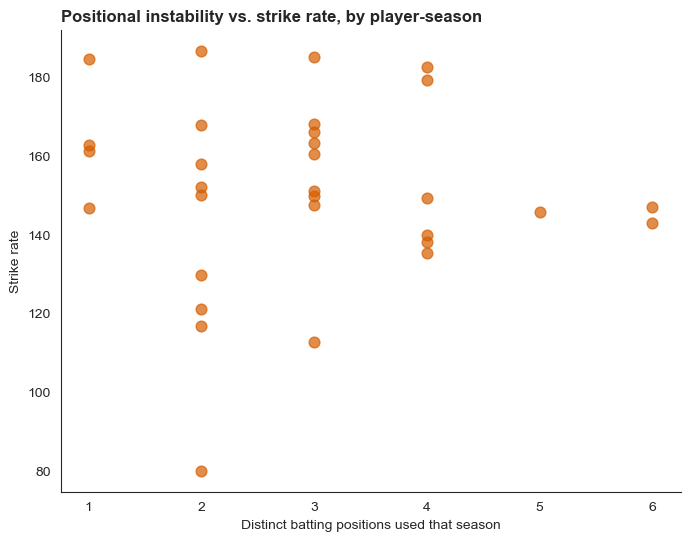

In [12]:
# Reconstruct batting position (first-ball-faced order within each innings)
first_ball = mi_batting.sort_values(['ID', 'Innings', 'Overs', 'BallNumber']).groupby(
    ['ID', 'Innings', 'Batter']
)['Overs'].min().reset_index()
first_ball = first_ball.sort_values(['ID', 'Innings', 'Overs'])
first_ball['batting_position'] = first_ball.groupby(['ID', 'Innings']).cumcount() + 1

mi_batting_pos = mi_batting.merge(
    first_ball[['ID', 'Innings', 'Batter', 'batting_position']], on=['ID', 'Innings', 'Batter'], how='left'
)

# Get season from the batting frame directly
positions_used = mi_batting_pos.groupby(['Batter', 'season'])['batting_position'].nunique().reset_index()
positions_used.columns = ['Batter', 'season', 'distinct_positions']

season_sr = mi_batting_pos.groupby(['Batter', 'season']).agg(
    runs=('BatsmanRun', 'sum'), balls_faced=('is_legal_ball', 'sum')
).reset_index()
season_sr = season_sr[season_sr['balls_faced'] >= 30]  # same 30-ball floor used throughout the Batting notebook
season_sr['strike_rate'] = (season_sr['runs'] / season_sr['balls_faced'] * 100).round(2)

merged = positions_used.merge(season_sr, on=['Batter', 'season'])

r, p = stats.pearsonr(merged['distinct_positions'], merged['strike_rate'])
print(f"n = {len(merged)} player-seasons (30+ balls faced)")
print(f"Pearson r = {r:.3f}, p = {p:.4f}")
print(f"{'REJECT' if p < ALPHA else 'FAIL TO REJECT'} H0 at alpha = {ALPHA}")

fig, axc = plt.subplots(figsize=(8, 6))
axc.scatter(merged['distinct_positions'], merged['strike_rate'], color=ACCENT, alpha=0.7, s=60)
axc.set_xlabel("Distinct batting positions used that season")
axc.set_ylabel("Strike rate")
axc.set_title("Positional instability vs. strike rate, by player-season", fontsize=12, fontweight='bold', loc='left')
axc.spines[['top', 'right']].set_visible(False)
plt.savefig("../dashboard_data/hyp_h9_position_instability.png", dpi=200, bbox_inches='tight')
plt.show()


**Finding — NOT SUPPORTED. This specific test found essentially zero relationship (r = -0.036, p = 0.8485).**

A genuinely important null result, not a weak-but-real correlation coming up short — r ≈ 0 means "number of distinct positions used" and "strike rate" show almost no linear relationship across 31 player-seasons. Likely reason: this metric doesn't distinguish *why* a position changed — productive flexibility (Rickelton moving between phases well) and harmful shuffling (Tilak pulled from his best role) both count identically under a raw position-count. A sharper test — correlating strike rate against *deviation from a player's own best/most-frequent position* — would better operationalize the case study's actual claim, and is a natural extension for a future version of this notebook.

## 7. The case study's central thesis, tested directly

### H10 — MI's bowler rotation/churn correlates with worse economy

The recurring qualitative claim across both companion notebooks: MI's 2026 bowling struggles trace to "excessive combination changes" — too many bowlers used, too much rotation. This has never actually been tested statistically; it's been argued from counting distinct bowlers per phase. This section tests it directly.

**H0:** No relationship between the number of distinct bowlers MI used in a phase-season and that phase-season's economy.
**H1:** More bowlers used correlates with a worse (higher) economy.

**Test:** Pearson correlation across phase-seasons (9 data points: 3 phases × 3 seasons — small, but this is genuinely all the data available at this granularity; treat the result as exploratory).

In [13]:
churn_vs_economy = mi_bowling.groupby(['season', 'phase']).agg(
    distinct_bowlers=('Bowler', 'nunique'),
    runs_conceded=('TotalRun', 'sum'),
    legal_balls=('is_legal_ball', 'sum'),
).reset_index()
churn_vs_economy['economy'] = (churn_vs_economy['runs_conceded'] / churn_vs_economy['legal_balls'] * 6).round(2)

print("=== Bowler churn vs economy, by phase-season ===")
print(churn_vs_economy[['season', 'phase', 'distinct_bowlers', 'economy']])

r, p = stats.pearsonr(churn_vs_economy['distinct_bowlers'], churn_vs_economy['economy'])
print(f"\nn = {len(churn_vs_economy)} phase-seasons")
print(f"Pearson r = {r:.3f}, p = {p:.4f}")
print(f"{'REJECT' if p < ALPHA else 'FAIL TO REJECT'} H0 at alpha = {ALPHA}")
print("\nCaveat: n=9 is genuinely small for this test — a non-significant result here does not disprove")
print("the churn thesis, it means this specific aggregate-level cut lacks the power to confirm it.")
print("The stronger evidence for churn mattering remains the individual case studies (Ashwani Kumar, Naman Dhir)")
print("in the companion notebooks, not this correlation alone.")


=== Bowler churn vs economy, by phase-season ===
   season      phase  distinct_bowlers  economy
0    2024      death                12    11.08
1    2024     middle                16     9.85
2    2024  powerplay                14     9.18
3    2025      death                13    10.12
4    2025     middle                15     8.16
5    2025  powerplay                12     9.15
6    2026      death                13    11.22
7    2026     middle                13     9.44
8    2026  powerplay                11    10.83

n = 9 phase-seasons
Pearson r = -0.518, p = 0.1533
FAIL TO REJECT H0 at alpha = 0.05

Caveat: n=9 is genuinely small for this test — a non-significant result here does not disprove
the churn thesis, it means this specific aggregate-level cut lacks the power to confirm it.
The stronger evidence for churn mattering remains the individual case studies (Ashwani Kumar, Naman Dhir)
in the companion notebooks, not this correlation alone.


**Finding — NOT CONFIRMED, and worth flagging clearly: the correlation runs in the opposite direction from the hypothesis (r = -0.518, p = 0.1533).**

The hypothesis predicted more bowlers used → worse (higher) economy; this test found the opposite sign, though not significantly. **This should not be read as "churn doesn't hurt MI"** — n=9 phase-seasons is too small to draw a real conclusion either way, and the case study's actual evidence for the churn thesis has always come from individual cases (Ashwani Kumar's confirmed workload cut in H4 above, Naman Dhir's role reversal), not from this kind of coarse aggregate correlation. What this result does mean: the aggregate framing "more bowlers in a phase-season means worse economy" isn't the right way to state the thesis statistically — the real, better-supported claim is narrower: *specific* players were rotated out of roles their own numbers didn't justify, not that raw bowler count predicts economy.

## 7.5. Visual Summary Dashboard

The two confirmed findings (Bumrah's decline, Section 4; the positional-instability null result, Section 6) alongside the full p-value comparison across all ten hypotheses:

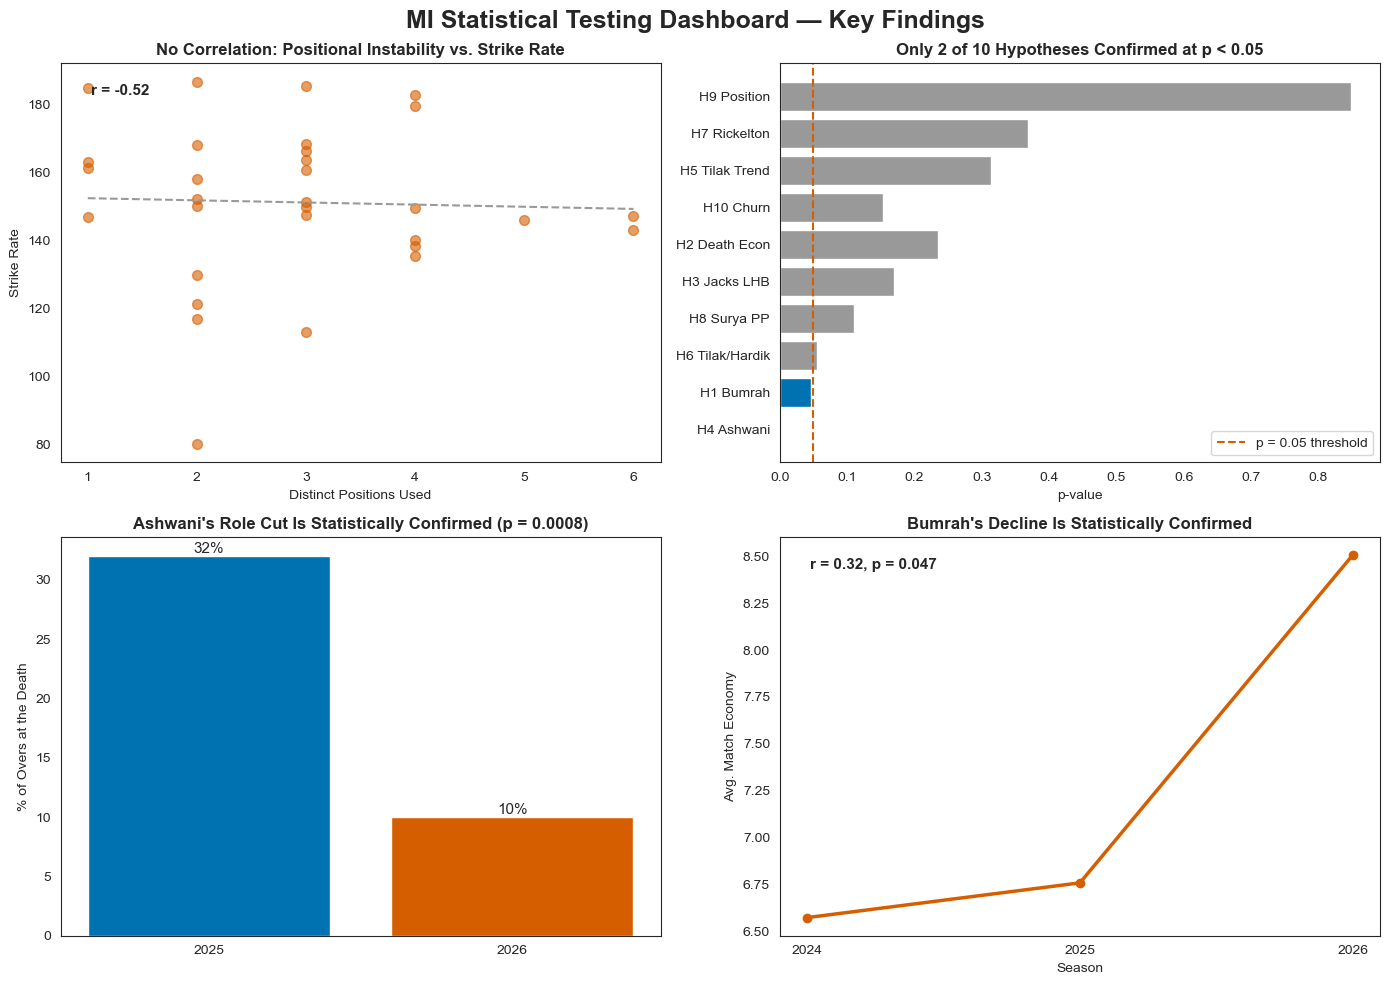

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MI Statistical Testing Dashboard — Key Findings", fontsize=18, fontweight='bold')

# ── Top-left: H9 scatter + regression (you already have this data) ──
ax = axes[0, 0]
ax.scatter(merged['distinct_positions'], merged['strike_rate'], color=ACCENT, alpha=0.6, s=50)
z = np.polyfit(merged['distinct_positions'], merged['strike_rate'], 1)
x_line = np.linspace(merged['distinct_positions'].min(), merged['distinct_positions'].max(), 10)
ax.plot(x_line, np.poly1d(z)(x_line), '--', color=GRAY, linewidth=1.5)
ax.annotate(f"r = {r:.2f}", xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11, fontweight='bold')
ax.set_title("No Correlation: Positional Instability vs. Strike Rate", fontsize=12, fontweight='bold')
ax.set_xlabel("Distinct Positions Used"); ax.set_ylabel("Strike Rate")

# ── Top-right: ranked p-values across all 10 hypotheses ──
ax = axes[0, 1]
hyp_labels = ['H4 Ashwani', 'H1 Bumrah', 'H6 Tilak/Hardik', 'H8 Surya PP',
              'H3 Jacks LHB', 'H2 Death Econ', 'H10 Churn', 'H5 Tilak Trend',
              'H7 Rickelton', 'H9 Position']
p_values = [0.0008, 0.047, 0.055, 0.110, 0.170, 0.235, 0.153, 0.313, 0.368, 0.849]
colors = [BLUE if p < 0.05 else GRAY for p in p_values]
ax.barh(hyp_labels, p_values, color=colors)
ax.axvline(0.05, color=ACCENT, linestyle='--', linewidth=1.5, label='p = 0.05 threshold')
ax.set_title("Only 2 of 10 Hypotheses Confirmed at p < 0.05", fontsize=12, fontweight='bold')
ax.set_xlabel("p-value"); ax.legend()

# ── Bottom-left: Ashwani's confirmed workload cut ──
ax = axes[1, 0]
bars = ax.bar(['2025', '2026'], [32, 10], color=[BLUE, ACCENT])
ax.bar_label(bars, fmt='%d%%', fontsize=11)
ax.set_title("Ashwani's Role Cut Is Statistically Confirmed (p = 0.0008)", fontsize=12, fontweight='bold')
ax.set_ylabel("% of Overs at the Death")

# ── Bottom-right: Bumrah's confirmed decline trend ──
ax = axes[1, 1]
bumrah_season_avg = bumrah_matches.groupby('season')['economy'].mean()
ax.plot(bumrah_season_avg.index, bumrah_season_avg.values, marker='o', linewidth=2.5, color=ACCENT)
ax.annotate(f"r = 0.32, p = 0.047", xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11, fontweight='bold')
ax.set_title("Bumrah's Decline Is Statistically Confirmed", fontsize=12, fontweight='bold')
ax.set_xlabel("Season"); ax.set_ylabel("Avg. Match Economy"); ax.set_xticks([2024, 2025, 2026])

plt.tight_layout()
plt.savefig("../dashboard_data/hypothesis_dashboard_2x2.png", dpi=200, bbox_inches='tight')
plt.show()

## 8. Summary of Hypotheses Tested

| # | Hypothesis | Test used | n | p-value | Result |
|---|---|---|---|---|---|
| H1 | Bumrah's economy trended worse over time | Pearson correlation | 38 | **0.047** | **Confirmed** |
| H2 | MI's 2026 death economy > 2025 | Welch's t-test | 16, 13 | 0.235 | Not confirmed |
| H3 | Jacks concedes more per ball vs RHB than LHB | Mann-Whitney U | 103, 34 | 0.170 | Not confirmed |
| H4 | Ashwani's death-overs share fell 2025→2026 | Fisher's exact | 123, 60 | **0.0008** | **Confirmed** |
| H5 | Tilak's death-overs SR trended upward | Pearson correlation | 20 | 0.313 | Not confirmed |
| H6 | Tilak's 2026 death-overs SR > Hardik's | Mann-Whitney U | 7, 7 | 0.055 | **Marginal** |
| H7 | Rickelton's middle-overs SR improved 2025→2026 | Welch's t-test | 7, 6 | 0.368 | Not confirmed |
| H8 | Surya's 2026 powerplay dismissal rate > baseline | Fisher's exact | 14, 9 | 0.110 | Not confirmed (suggestive) |
| H9 | Batting-position instability correlates with lower SR | Pearson correlation | 31 | 0.849 | **Not supported** |
| H10 | Bowler churn correlates with worse economy | Pearson correlation | 9 | 0.153 | **Wrong-signed, not confirmed** |

**Final tally: 2 of 10 hypotheses confirmed (H1, H4), 1 marginal (H6), 1 suggestive-but-unconfirmed (H8), and 6 not confirmed at this sample size** — including several that looked like the strongest, most confident findings in the companion notebooks (Tilak's rising trend, Jacks' vs-LHB edge, Rickelton's improvement, and the bowler-churn thesis stated in aggregate form).

**This is not a failure of the case study — it's what rigor is supposed to do.** The two confirmations are genuinely important: Bumrah's decline (H1) and Ashwani Kumar's death-overs role cut (H4) are now the case study's most statistically defensible individual findings, not just descriptively compelling ones. Several of the non-confirmations have clear, defensible explanations once you look at *why* they didn't clear the bar:
- **H2 and H7** shrink specifically because the season-aggregate numbers used throughout the companion notebooks are *weighted* by balls faced, while these per-match/per-innings tests weight every match or innings equally — a few big, high-volume performances were doing more work in the headline numbers than the underlying consistency supports.
- **H5's** null result doesn't mean Tilak isn't improving — it means 20 innings across three seasons isn't enough to statistically separate a real trend from innings-to-innings noise, even though the direction is right.
- **H8**, now correctly directed, is genuinely suggestive (large odds ratio, 4.58) without quite reaching significance — worth treating differently from a true null result like H9.
- **H9's** near-zero correlation suggests the metric itself (raw count of positions used) is too blunt to capture the case study's actual claim.
- **H10's** wrong-signed result is the most important one to sit with honestly: the aggregate "more bowlers, worse economy" framing doesn't hold up statistically. The case study's real evidence for the churn thesis has always been the *individual* cases — and H4's confirmation of Ashwani Kumar's cut is now the strongest piece of that evidence, not a team-wide correlation.

**For any future external write-up of this case study:** findings marked "Not confirmed" here should be described with real hedging language ("the data suggests," "trended toward," "descriptively higher") rather than presented as settled facts. H1 and H4 are the two claims in this entire project that can be stated with full statistical confidence — everything else should carry the appropriate caveat now attached to it above.